In [ ]:
import seaborn as sns
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend, plot, show, title, xlabel,ylabel
import pandas as pd

In [ ]:
df = pd.read_csv("6-Churn_ModellingDataSet.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [ ]:
exit_counts = df.Exited.value_counts()
exit_counts

,count
Exited,
0,7963
1,2037


In [ ]:
exit_prop = pd.DataFrame(exit_counts)
exit_prop

,count
Exited,
0,7963
1,2037


In [ ]:
exit_prop['proportion'] = exit_prop['count']/sum(exit_prop['count'])
exit_prop

,count,proportion
Exited,,
0,7963,0.7963
1,2037,0.2037


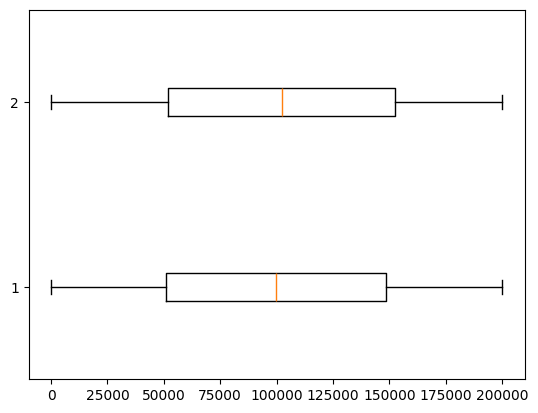

In [ ]:
# Does the salary has any affect on exited or not plot the graph
df0 = df[df.Exited == 0]
df1 = df[df.Exited == 1]
plt.boxplot([df0.EstimatedSalary, df1.EstimatedSalary], vert=False)
plt.show()

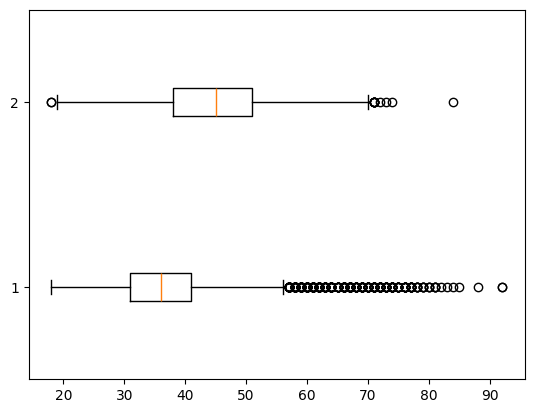

In [ ]:
# Does the age has any effect on exited or not
df0 = df[df.Exited == 0]
df1 = df[df.Exited == 1]
plt.boxplot([df0.Age, df1.Age], vert=False)
plt.show()

In [ ]:
np.median(df0.Age)
np.median(df1.Age)

np.float64(45.0)

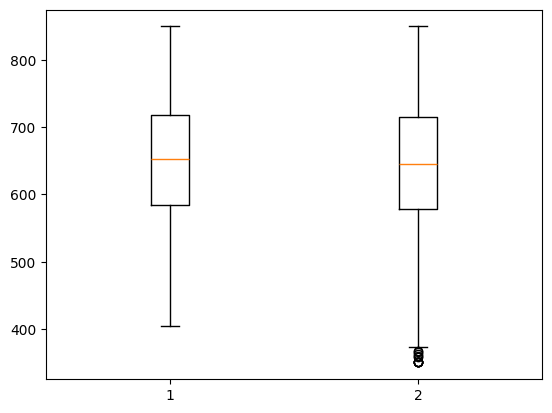

In [ ]:
# Does the credit score has any effect on exited or not
df0 = df[df.Exited == 0]
df1 = df[df.Exited == 1]
plt.boxplot([df0.CreditScore, df1.CreditScore])
plt.show()

In [ ]:
df_400 = df.iloc[np.where(df.CreditScore<400)]
df_400.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1201,399,Germany,Male,46,2,127655.22,1,1,0,139994.68,1
1405,359,France,Female,44,6,128747.69,1,1,0,146955.71,1


In [ ]:
df_400.Exited.value_counts()

,count
Exited,
1,19


In [ ]:
df

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


<Axes: xlabel='Geography'>

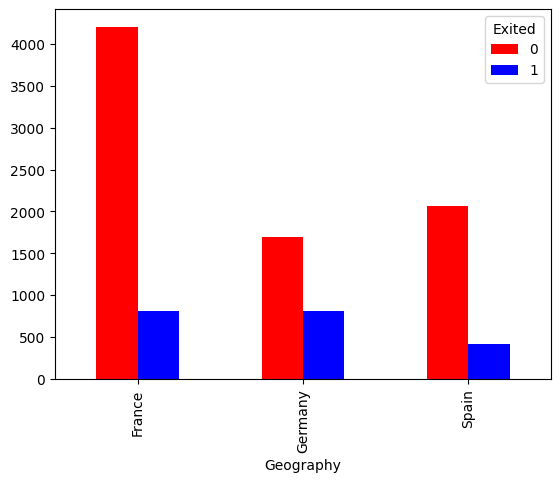

In [ ]:
# Does geography has any affect on exited or not (grouped bar chart) with quantity
df1 = pd.crosstab(df.Geography, df.Exited)
df1.plot(kind='bar', color=['red', 'blue'])

In [ ]:
# calculate the Proportion of people exited in France and germany
df1["proportion"] = df1[1]/(df1[0]+df1[1])
df1

Exited,0,1,proportion
Geography,,,
France,4204,810,0.161548
Germany,1695,814,0.324432
Spain,2064,413,0.166734


<Axes: xlabel='HasCrCard'>

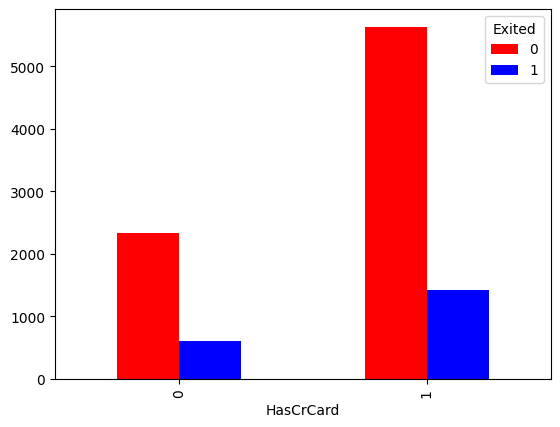

In [ ]:
# Does the person have the credit card affect the exited or not
df2 = pd.crosstab(df.HasCrCard, df.Exited)
df2.plot(kind='bar', color=['red', 'blue'])

In [ ]:
# Calculate the proportion of people exited based on hascrcard
df2['proportion'] = df2[1]/(df2[0]+df2[1])
df2

Exited,0,1,proportion
HasCrCard,,,
0,2332,613,0.208149
1,5631,1424,0.201843


<Axes: xlabel='Gender'>

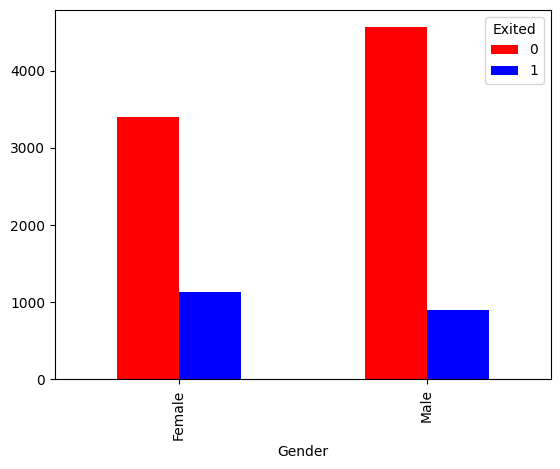

In [ ]:
# Does the gender affect the exited or not
df3 = pd.crosstab(df.Gender, df.Exited)
df3.plot(kind='bar', color=['red', 'blue'])

In [ ]:
# Calculating the proportion of people exited based on gender
df3['proportion'] = df3[1]/(df3[0]+df3[1])
df3

Exited,0,1,proportion
Gender,,,
Female,3404,1139,0.250715
Male,4559,898,0.164559


In [ ]:
pt = df.pivot_table(values='Exited', index='Geography', columns='Gender', aggfunc=np.sum)
pt

/tmp/ipykernel_591/597140740.py:1: FutureWarning: The provided callable <function sum at 0x7f8de95f8860> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pt = df.pivot_table(values='Exited', index='Geography', columns='Gender', aggfunc=np.sum)


Gender,Female,Male
Geography,,
France,460,350
Germany,448,366
Spain,231,182


In [ ]:
pt["prop"] = pt["Female"]/(pt["Female"]+pt["Male"])
pt

Gender,Female,Male,prop
Geography,,,
France,460,350,0.567901
Germany,448,366,0.550369
Spain,231,182,0.559322


In [ ]:
# Isactivemember has any affect on exited
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: xlabel='IsActiveMember'>

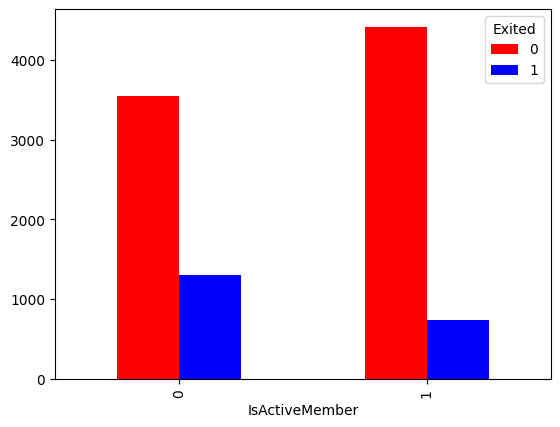

In [ ]:
is_active = pd.crosstab(df.IsActiveMember, df.Exited)
is_active.plot(kind='bar', color=['red', 'blue'])

In [ ]:
is_active

Exited,0,1
IsActiveMember,,
0,3547,1302
1,4416,735


In [ ]:
is_active['prop'] = is_active[1]/(is_active[0]+is_active[1])
is_active

Exited,0,1,prop
IsActiveMember,,,
0,3547,1302,0.268509
1,4416,735,0.142691
